# LV Schutterwald State Estimation Uncertainty Quantification

## Goal

This notebook compares five uncertainty-quantification methods for the `lv_schutterwald()` low-voltage network from pandapower:

1. analytical UQ with iterative-linear state estimation (ILSE);
2. analytical UQ with Newton–Raphson state estimation (NRSE);
3. conventional gain-inverse UQ at the NRSE operating point;
4. Monte Carlo UQ with ILSE; and
5. Monte Carlo UQ with NRSE.

The gain-inverse path builds $G=H^\mathsf{T}WH$ from sensor rows only. It deliberately excludes exact zero-injection constraints; one angle coordinate is removed in each otherwise unanchored feeder measurement subnetwork.

| Plot label | State estimator | Uncertainty calculation | Exact zero injection |
|---|---|---|---|
| Analytical UQ ILSE | ILSE | PGM analytical propagation | Included |
| Analytical UQ NRSE | NRSE | PGM analytical propagation | Included |
| UQ gain inv | Converged NRSE operating point | $G^{-1}$ plus first-order output propagation | Excluded |
| Monte Carlo UQ ILSE | ILSE | Sample standard deviation, $N=1{,}000$ | Included |
| Monte Carlo UQ NRSE | NRSE | Sample standard deviation, $N=1{,}000$ | Included |

**Sensor-layout note.** This notebook currently uses the voltage-plus-power layout: voltage sensors at the 14 source buses and power sensors at all 3,000 line and 14 transformer to-terminals. The voltage-plus-current and combined layouts are not included because the network contains zero-current branches; placing current sensors on every line produces invalid or unstable state-estimation inputs. These layouts can be added later after filtering and validating the current-sensor locations.

The network is substantially larger than IEEE33: it has 2,940 buses, 3,000 lines, 14 transformers, and 1,506 loads. It has no PV generators or static generators, making it a useful large-network example for the PGM pandapower converter.

The full PGM input is stored in `data/lv_schutterwald_pgm.json`, with a path fallback for running from either the repository root or `docs/examples`.


## Setup

The input was generated with the repository helper script using `pandapower.networks.lv_schutterwald()` and the [Power Grid Model IO pandapower converter](https://power-grid-model-io.readthedocs.io/en/stable/converters/pandapower_converter.html). The converter preserves the network model but does not preserve pandapower plotting geodata, so the topology figure below uses a deterministic breadth-first layout.


In [1]:
import json
import sys
from collections import deque
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import power_grid_model
from power_grid_model import (
    AttributeType,
    CalculationMethod,
    CalculationType,
    ComponentType,
    DatasetType,
    MeasuredTerminalType,
    PowerGridModel,
    initialize_array,
)
from power_grid_model._core.power_grid_model_c.get_pgm_dll_path import get_pgm_dll_path
from power_grid_model.utils import create_state_estimation_monte_carlo_updates
from power_grid_model.validation import assert_valid_input_data

example_directory = Path("docs/examples") if Path("docs/examples").is_dir() else Path()
example_directory_string = str(example_directory.resolve())
if example_directory_string not in sys.path:
    sys.path.insert(0, example_directory_string)
from gain_covariance import propagate_covariance
from gain_matrix import build_gain_matrix

output_directory = (
    Path("docs/examples/output/lv_schutterwald") if Path("docs/examples").is_dir() else Path("output/lv_schutterwald")
)
output_directory.mkdir(parents=True, exist_ok=True)
figure_directory = output_directory / "figures"
figure_directory.mkdir(parents=True, exist_ok=True)

print("Python:", sys.executable)
print("Power Grid Model package:", power_grid_model.__file__)
print("Native library:", get_pgm_dll_path())

Python: /home/jhe/pgm_dev/power-grid-model/.venv/bin/python3
Power Grid Model package: /home/jhe/pgm_dev/power-grid-model/src/power_grid_model/__init__.py
Native library: /home/jhe/pgm_dev/power-grid-model/build/bin/libpower_grid_model_c.so


In [2]:
data_file_candidates = [
    Path("data/lv_schutterwald_pgm.json"),
    Path("docs/examples/data/lv_schutterwald_pgm.json"),
]
data_file = next((path for path in data_file_candidates if path.exists()), None)
if data_file is None:
    raise FileNotFoundError(
        "Could not find lv_schutterwald_pgm.json. Run this notebook from the repository root or from docs/examples."
    )
with data_file.open() as file:
    workshop_model = json.load(file)


def deserialize_workshop_model(component_rows):
    input_data = {}
    for component_name, rows in component_rows.items():
        component = ComponentType(component_name)
        array = initialize_array(DatasetType.input, component, len(rows))
        common_fields = set(rows[0]).intersection(array.dtype.names)
        for row in rows[1:]:
            common_fields.intersection_update(row)
        for field in sorted(common_fields):
            array[field] = [row[field] for row in rows]
        input_data[component] = array
    return input_data


base_input_data = deserialize_workshop_model(workshop_model)
assert_valid_input_data(
    base_input_data,
    calculation_type=CalculationType.power_flow,
    symmetric=True,
)
network_counts = {str(component): len(values) for component, values in base_input_data.items()}
print(network_counts)
expected_node_count = 2_940
expected_line_count = 3_000
if len(base_input_data[ComponentType.node]) != expected_node_count:
    raise ValueError(f"Expected {expected_node_count} nodes")
if len(base_input_data[ComponentType.line]) != expected_line_count:
    raise ValueError(f"Expected {expected_line_count} lines")
if ComponentType.sym_gen in base_input_data:
    raise ValueError("LV Schutterwald must not contain symmetric generators")

{'node': 2940, 'line': 3000, 'source': 14, 'sym_load': 4518, 'transformer': 14}


## LV Schutterwald topology

The topology plot includes the network size in its title. Because the network has thousands of buses and branches, node labels are omitted and the graph is laid out by distance from the first source.


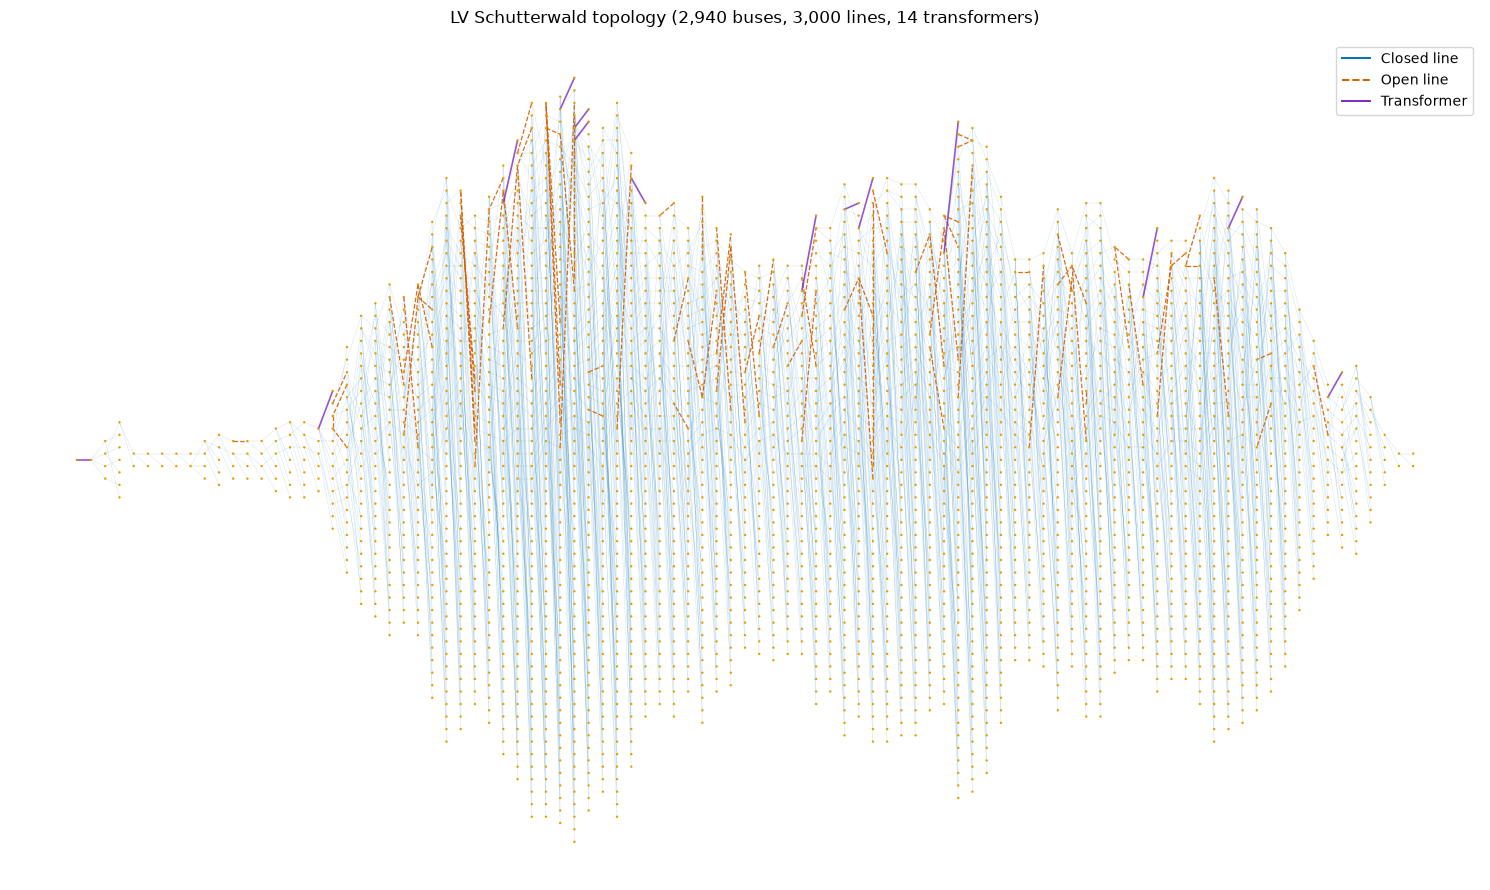

In [3]:
node_ids_for_plot = [int(node_id) for node_id in base_input_data[ComponentType.node][AttributeType.id]]
line_rows = {int(row[AttributeType.id]): row for row in base_input_data[ComponentType.line]}
transformer_rows = {int(row[AttributeType.id]): row for row in base_input_data[ComponentType.transformer]}
topology_edges = [(int(row[AttributeType.from_node]), int(row[AttributeType.to_node])) for row in line_rows.values()]
topology_edges.extend(
    (int(row[AttributeType.from_node]), int(row[AttributeType.to_node])) for row in transformer_rows.values()
)
adjacency = {node_id: [] for node_id in node_ids_for_plot}
for from_node, to_node in topology_edges:
    adjacency[from_node].append(to_node)
    adjacency[to_node].append(from_node)
source_nodes = [int(node_id) for node_id in base_input_data[ComponentType.source][AttributeType.node]]
root_node = source_nodes[0]
depth = {root_node: 0}
queue = deque([root_node])
while queue:
    node_id = queue.popleft()
    for neighbor in adjacency[node_id]:
        if neighbor not in depth:
            depth[neighbor] = depth[node_id] + 1
            queue.append(neighbor)
for node_id in node_ids_for_plot:
    if node_id not in depth:
        depth[node_id] = max(depth.values(), default=0) + 1

topology_positions = {}
for depth_value in range(max(depth.values(), default=0) + 1):
    level_nodes = [node_id for node_id in node_ids_for_plot if depth[node_id] == depth_value]
    level_center = (len(level_nodes) - 1) / 2.0
    for level_index, node_id in enumerate(level_nodes):
        topology_positions[node_id] = (float(depth_value), float(level_index - level_center))

network_size_label = (
    f"{len(node_ids_for_plot):,} buses, {len(line_rows):,} lines, {len(transformer_rows):,} transformers"
)
with plt.style.context(["default"]), plt.rc_context({"text.usetex": False}):
    topology_figure, topology_axis = plt.subplots(figsize=(15, 9))
    for row in line_rows.values():
        from_node = int(row[AttributeType.from_node])
        to_node = int(row[AttributeType.to_node])
        is_closed = bool(row[AttributeType.from_status]) and bool(row[AttributeType.to_status])
        topology_axis.plot(
            [topology_positions[from_node][0], topology_positions[to_node][0]],
            [topology_positions[from_node][1], topology_positions[to_node][1]],
            color="#0072B2" if is_closed else "#D55E00",
            linestyle="-" if is_closed else "--",
            linewidth=0.25 if is_closed else 0.9,
            alpha=0.25 if is_closed else 0.9,
        )
    for row in transformer_rows.values():
        from_node = int(row[AttributeType.from_node])
        to_node = int(row[AttributeType.to_node])
        topology_axis.plot(
            [topology_positions[from_node][0], topology_positions[to_node][0]],
            [topology_positions[from_node][1], topology_positions[to_node][1]],
            color="#7B2CBF",
            linewidth=1.2,
            alpha=0.8,
        )
    topology_axis.scatter(
        [topology_positions[node_id][0] for node_id in node_ids_for_plot],
        [topology_positions[node_id][1] for node_id in node_ids_for_plot],
        s=3,
        color="#E69F00",
        edgecolor="none",
        zorder=3,
    )
    topology_axis.set_title(f"LV Schutterwald topology ({network_size_label})", pad=12)
    topology_axis.axis("off")
    topology_axis.legend(
        handles=[
            plt.Line2D([0], [0], color="#0072B2", linewidth=1.4, label="Closed line"),
            plt.Line2D([0], [0], color="#D55E00", linestyle="--", linewidth=1.4, label="Open line"),
            plt.Line2D([0], [0], color="#7B2CBF", linewidth=1.4, label="Transformer"),
        ],
        loc="upper right",
    )
    topology_figure.tight_layout()
    topology_figure.savefig(figure_directory / "lv_schutterwald_topology.pdf")
    topology_figure.savefig(figure_directory / "lv_schutterwald_topology.png", dpi=300)
    plt.show()
    plt.close(topology_figure)

## Build the sensor layout

The default LV Schutterwald model has 14 external-grid sources, one for each MV/LV transformer station. We place voltage sensors at those source buses and power sensors at the to-terminal of every line and transformer. This keeps the sensor-only gain matrix observable without introducing current sensors on zero-current branches or relying on exact zero-injection constraints.


In [4]:
power_flow = PowerGridModel(
    base_input_data,
    system_frequency=50.0,
).calculate_power_flow(
    symmetric=True,
    calculation_method=CalculationMethod.newton_raphson,
    error_tolerance=1e-8,
    max_iterations=50,
)

node_ids = base_input_data[ComponentType.node][AttributeType.id]
node_index = {int(node_id): index for index, node_id in enumerate(node_ids)}
line_ids = base_input_data[ComponentType.line][AttributeType.id]
branch_components = [ComponentType.line, ComponentType.transformer]
branch_ids = np.concatenate([base_input_data[component_type][AttributeType.id] for component_type in branch_components])
source_nodes = base_input_data[ComponentType.source][AttributeType.node]
source_indices = np.array([node_index[int(node_id)] for node_id in source_nodes])

voltage_sigma = 10.0
voltage_angle_sigma = 0.01
power_p_sigma = 5_000.0
power_q_sigma = 5_000.0
rng = np.random.default_rng(42)
max_component_id = max(int(values[AttributeType.id].max()) for values in base_input_data.values())

voltage_sensor = initialize_array(
    DatasetType.input,
    ComponentType.sym_voltage_sensor,
    len(source_nodes),
)
voltage_sensor[AttributeType.id] = np.arange(
    max_component_id + 1,
    max_component_id + 1 + len(source_nodes),
)
voltage_sensor[AttributeType.measured_object] = source_nodes
voltage_sensor[AttributeType.u_sigma] = voltage_sigma
voltage_sensor[AttributeType.u_measured] = power_flow[ComponentType.node][AttributeType.u][source_indices] + rng.normal(
    0.0, voltage_sigma, len(source_nodes)
)
voltage_sensor[AttributeType.u_angle_measured] = power_flow[ComponentType.node][AttributeType.u_angle][
    source_indices
] + rng.normal(0.0, voltage_angle_sigma, len(source_nodes))

power_sensor = initialize_array(
    DatasetType.input,
    ComponentType.sym_power_sensor,
    len(branch_ids),
)
power_sensor[AttributeType.id] = np.arange(
    max_component_id + 1 + len(source_nodes),
    max_component_id + 1 + len(source_nodes) + len(branch_ids),
)
power_sensor[AttributeType.measured_object] = branch_ids
power_sensor[AttributeType.measured_terminal_type] = MeasuredTerminalType.branch_to
power_sensor[AttributeType.p_sigma] = power_p_sigma
power_sensor[AttributeType.q_sigma] = power_q_sigma
p_to = np.concatenate([power_flow[component_type][AttributeType.p_to] for component_type in branch_components])
q_to = np.concatenate([power_flow[component_type][AttributeType.q_to] for component_type in branch_components])
power_sensor[AttributeType.p_measured] = p_to + rng.normal(0.0, power_p_sigma, len(branch_ids))
power_sensor[AttributeType.q_measured] = q_to + rng.normal(0.0, power_q_sigma, len(branch_ids))

state_estimation_input = base_input_data | {
    ComponentType.sym_voltage_sensor: voltage_sensor,
    ComponentType.sym_power_sensor: power_sensor,
}
assert_valid_input_data(
    state_estimation_input,
    calculation_type=CalculationType.state_estimation,
    symmetric=True,
)
print(
    {
        "voltage sensors": len(voltage_sensor),
        "power sensors": len(power_sensor),
        "source buses": len(source_nodes),
    }
)

{'voltage sensors': 14, 'power sensors': 3014, 'source buses': 14}


## Analytical UQ and conventional gain inverse

The conventional gain inverse uses the same converged NRSE operating point, but its $H$, $W$, and $G$ contain sensor information only; PGM exact zero-injection constraints are excluded.


In [5]:
methods = {
    "Analytical UQ ILSE": CalculationMethod.iterative_linear,
    "Analytical UQ NRSE": CalculationMethod.newton_raphson,
}
analytical_results = {}
analytical_seconds = {}
deterministic_seconds = {}
gain_inverse_result = None

for method_name, calculation_method in methods.items():
    model = PowerGridModel(state_estimation_input, system_frequency=50.0)
    start = perf_counter()
    without_uq = model.calculate_state_estimation(
        calculation_method=calculation_method,
        error_tolerance=1e-8,
        max_iterations=50,
    )
    deterministic_seconds[method_name] = perf_counter() - start
    start = perf_counter()
    with_uq = model.calculate_state_estimation(
        calculation_method=calculation_method,
        calculate_uncertainty=True,
        error_tolerance=1e-8,
        max_iterations=50,
    )
    analytical_seconds[method_name] = perf_counter() - start
    for component in (ComponentType.node, ComponentType.line):
        for field in ("u", "u_angle", "p", "q", "i_from", "i_to"):
            if field in with_uq[component].dtype.names:
                np.testing.assert_allclose(
                    with_uq[component][field],
                    without_uq[component][field],
                )
    analytical_results[method_name] = with_uq

nrse_result = analytical_results["Analytical UQ NRSE"]
gain_model = build_gain_matrix(
    state_estimation_input,
    state_estimation_result=nrse_result,
    max_gain_matrix_bytes=None,
)
measurement_model = gain_model.measurement_model
gain_inverse = np.linalg.inv(gain_model.gain_matrix)
del gain_model
gain_inverse_result = propagate_covariance(
    state_estimation_input,
    measurement_model,
    gain_inverse,
    nrse_result,
)
del gain_inverse

pd.DataFrame(
    [
        {
            "method": method_name,
            "deterministic time [s]": deterministic_seconds[method_name],
            "analytical UQ time [s]": analytical_seconds[method_name],
        }
        for method_name in methods
    ]
).round(3)

,method,deterministic time [s],analytical UQ time [s]
0,Analytical UQ ILSE,0.005,0.040
1,Analytical UQ NRSE,0.007,0.053


## Monte Carlo UQ

The sample count is intentionally modest for this 2,940-bus example. Increase it for a more precise empirical standard deviation when running on a machine with sufficient time and memory.


In [6]:
monte_carlo_sample_count = 20
monte_carlo_results = {}
monte_carlo_valid = {}
monte_carlo_seconds = {}

updates = create_state_estimation_monte_carlo_updates(
    state_estimation_input,
    monte_carlo_sample_count,
    seed=2026,
)
for method_name, calculation_method in methods.items():
    model = PowerGridModel(state_estimation_input, system_frequency=50.0)
    start = perf_counter()
    batch_result = model.calculate_state_estimation(
        calculation_method=calculation_method,
        update_data=updates,
        error_tolerance=1e-8,
        max_iterations=50,
        continue_on_batch_error=True,
    )
    elapsed = perf_counter() - start
    failed = [] if model.batch_error is None else model.batch_error.failed_scenarios
    valid = np.ones(monte_carlo_sample_count, dtype=bool)
    valid[failed] = False
    if np.count_nonzero(valid) < 0.9 * monte_carlo_sample_count:
        raise RuntimeError(f"Too many failed Monte Carlo scenarios: {failed}")
    monte_carlo_results[method_name] = batch_result
    monte_carlo_valid[method_name] = valid
    monte_carlo_seconds[method_name] = elapsed

pd.DataFrame(
    [
        {
            "method": method_name.replace("Analytical", "Monte Carlo"),
            "attempted samples": monte_carlo_sample_count,
            "converged samples": int(np.count_nonzero(monte_carlo_valid[method_name])),
            "time [s]": monte_carlo_seconds[method_name],
        }
        for method_name in methods
    ]
)

,method,attempted samples,converged samples,time [s]
0,Monte Carlo UQ ILSE,20,20,0.080109
1,Monte Carlo UQ NRSE,20,20,0.130002


## Five-way comparison

The table below compares analytical and sensor-only gain-inverse output sigmas with empirical Monte Carlo standard deviations for voltage magnitude, branch current, and branch active power.


In [7]:
output_specs = []
for index, node_id in enumerate(node_ids):
    output_specs.append(
        {
            "component": "node",
            "id": int(node_id),
            "terminal": "—",
            "quantity": "voltage magnitude",
            "component_type": ComponentType.node,
            "value_field": "u",
            "sigma_field": "u_sigma",
            "index": index,
            "unit": "V",
        }
    )
for index, line_id in enumerate(line_ids):
    output_specs.extend(
        [
            {
                "component": "line",
                "id": int(line_id),
                "terminal": "from",
                "quantity": "current",
                "component_type": ComponentType.line,
                "value_field": "i_from",
                "sigma_field": "i_from_sigma",
                "index": index,
                "unit": "A",
            },
            {
                "component": "line",
                "id": int(line_id),
                "terminal": "from",
                "quantity": "active power",
                "component_type": ComponentType.line,
                "value_field": "p_from",
                "sigma_field": "p_from_sigma",
                "index": index,
                "unit": "W",
            },
        ]
    )

comparison_rows = []
for spec in output_specs:
    row = {
        "component": spec["component"],
        "id": spec["id"],
        "terminal": spec["terminal"],
        "quantity": spec["quantity"],
        "unit": spec["unit"],
    }
    for method_name in methods:
        analytical = analytical_results[method_name][spec["component_type"]][spec["sigma_field"]][spec["index"]]
        valid = monte_carlo_valid[method_name]
        sampled = monte_carlo_results[method_name][spec["component_type"]][spec["value_field"]][valid, spec["index"]]
        row[f"{method_name} sigma"] = float(analytical)
        row[f"Monte Carlo UQ {method_name.split()[-1]} sigma"] = float(np.std(sampled, ddof=1))
    row["UQ gain inv sigma"] = float(gain_inverse_result[spec["component_type"]][spec["sigma_field"]][spec["index"]])
    comparison_rows.append(row)

comparison = pd.DataFrame(comparison_rows)
numeric_columns = [
    "Analytical UQ ILSE sigma",
    "Analytical UQ NRSE sigma",
    "UQ gain inv sigma",
    "Monte Carlo UQ ILSE sigma",
    "Monte Carlo UQ NRSE sigma",
]
nonfinite_counts = {
    quantity: int((~np.isfinite(group[numeric_columns])).any(axis=1).sum())
    for quantity, group in comparison.groupby("quantity")
}
print("Rows with non-finite analytical sigma values:", nonfinite_counts)
comparison = comparison[["component", "id", "terminal", "quantity", "unit", *numeric_columns]]
comparison_file = output_directory / "lv_schutterwald_uq_comparison.csv"
comparison.to_csv(comparison_file, index=False)
print(f"Comparison rows: {len(comparison):,}")
print(f"Comparison table exported to {comparison_file}")
comparison.head()

Rows with non-finite analytical sigma values: {'active power': 1, 'current': 31, 'voltage magnitude': 0}
Comparison rows: 8,940
Comparison table exported to docs/examples/output/lv_schutterwald/lv_schutterwald_uq_comparison.csv


,component,id,terminal,quantity,unit,Analytical UQ ILSE sigma,Analytical UQ NRSE sigma,UQ gain inv sigma,Monte Carlo UQ ILSE sigma,Monte Carlo UQ NRSE sigma
0,node,0,—,voltage magnitude,V,0.995783,1.079812,1.137670,1.194916,1.192029
1,node,1,—,voltage magnitude,V,0.398691,0.454369,0.496969,0.357276,0.357284
2,node,2,—,voltage magnitude,V,0.316429,0.367025,0.384543,0.403883,0.403693
3,node,3,—,voltage magnitude,V,0.340148,0.391892,0.412958,0.436317,0.435906
4,node,4,—,voltage magnitude,V,0.345114,0.396680,0.421721,0.348907,0.348714


## Network-wide comparison figures

To keep the notebook and output directory practical for a network of this size, sigma figures show the first 30 finite node or branch IDs for each quantity. A small number of zero-flow branches can have undefined analytical current or power sigmas; those rows are retained as `NaN` in the complete CSV export.

Each ID has five bars. The `UQ gain inv` bar propagates the inverse of the sensor-only gain matrix and therefore does not include exact zero-injection constraints.


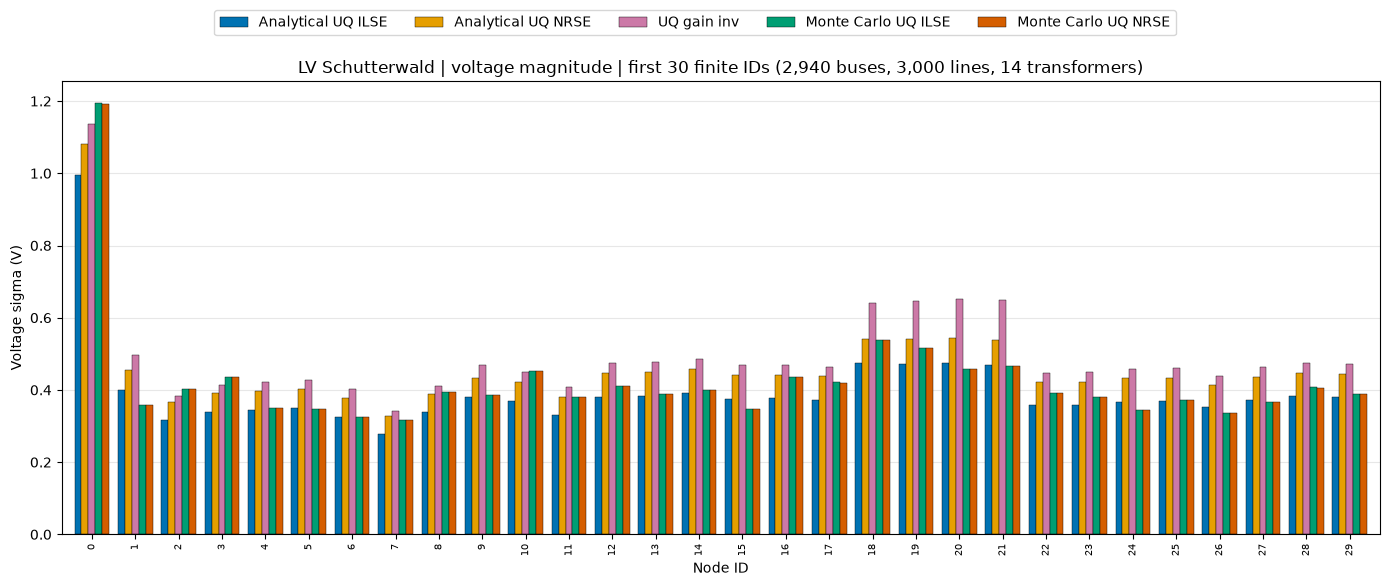

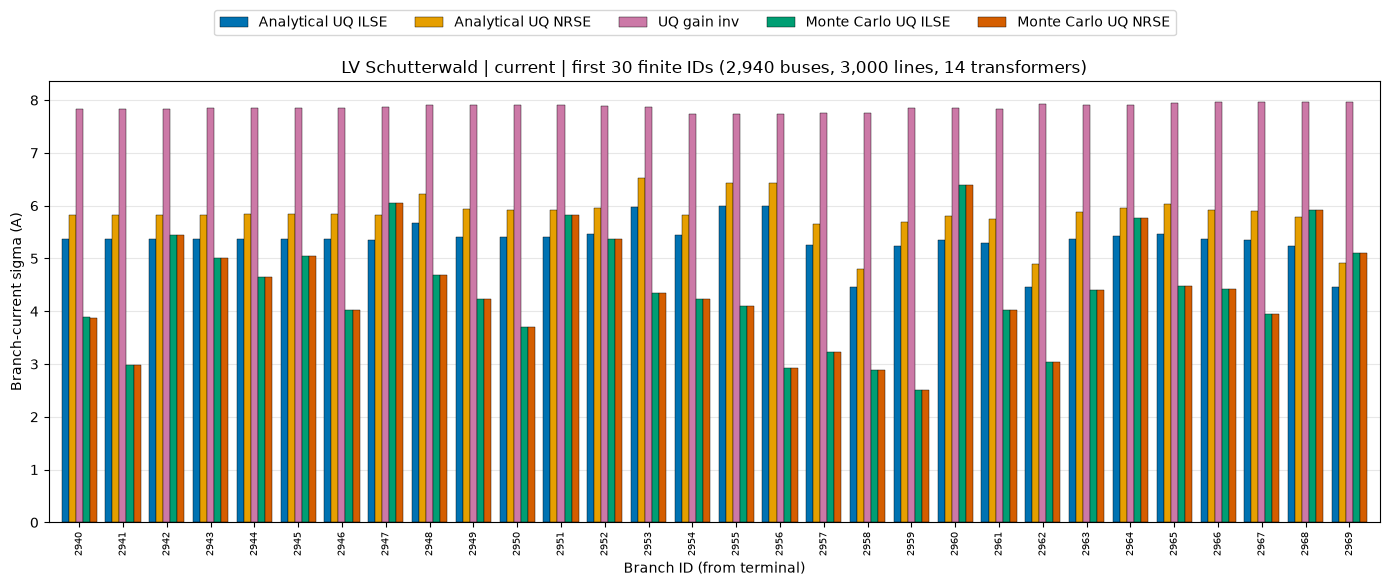

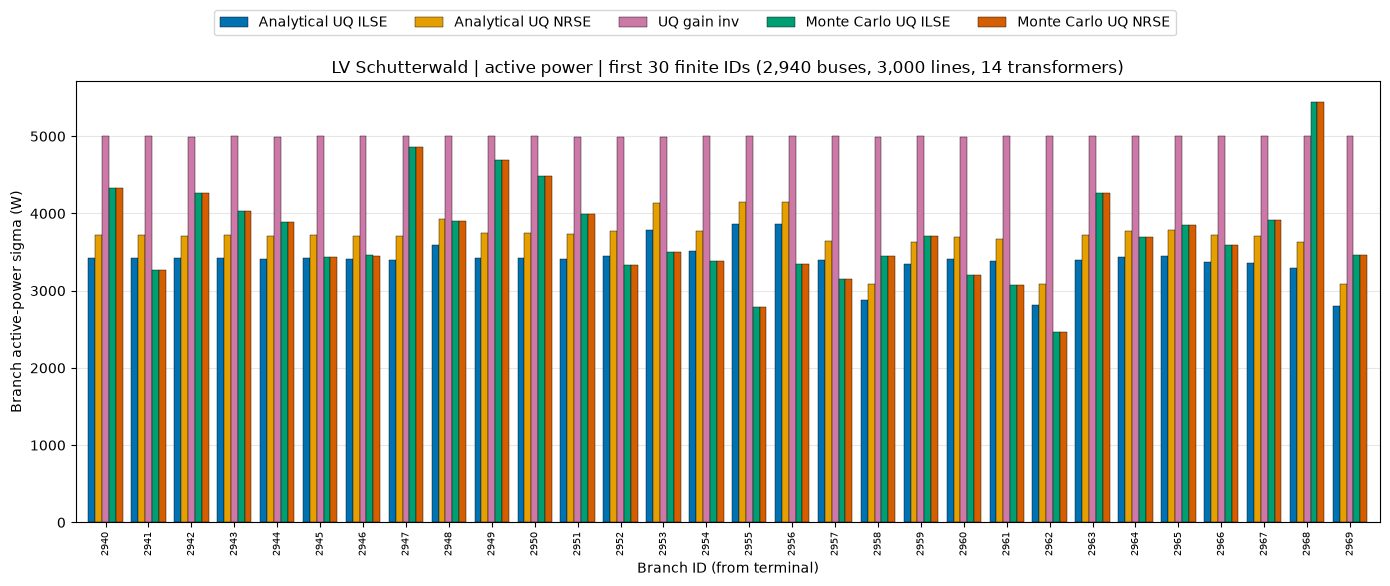

In [8]:
method_columns = [
    ("Analytical UQ ILSE sigma", "Analytical UQ ILSE", "#0072B2"),
    ("Analytical UQ NRSE sigma", "Analytical UQ NRSE", "#E69F00"),
    ("UQ gain inv sigma", "UQ gain inv", "#CC79A7"),
    ("Monte Carlo UQ ILSE sigma", "Monte Carlo UQ ILSE", "#009E73"),
    ("Monte Carlo UQ NRSE sigma", "Monte Carlo UQ NRSE", "#D55E00"),
]
plot_definitions = [
    ("node", "voltage magnitude", "Voltage sigma (V)", "Node ID"),
    ("line", "current", "Branch-current sigma (A)", "Branch ID (from terminal)"),
    ("line", "active power", "Branch active-power sigma (W)", "Branch ID (from terminal)"),
]


def plot_sigma_bars(axis, filtered, ylabel, xlabel):
    positions = np.arange(len(filtered))
    bar_width = 0.16
    offsets = (np.arange(len(method_columns)) - (len(method_columns) - 1) / 2) * bar_width
    for offset, (column, label, color) in zip(offsets, method_columns, strict=True):
        axis.bar(
            positions + offset,
            filtered[column].to_numpy(),
            width=bar_width,
            label=label,
            color=color,
            edgecolor="black",
            linewidth=0.3,
        )
    axis.set_xlabel(xlabel)
    axis.set_ylabel(ylabel)
    axis.set_xticks(positions)
    axis.set_xticklabels(filtered["id"].astype(str).tolist(), rotation=90, fontsize=7)
    axis.grid(axis="y", visible=True, alpha=0.3)
    axis.set_axisbelow(True)
    axis.margins(x=0.01)


for component, quantity, ylabel, xlabel in plot_definitions:
    filtered = (
        comparison[(comparison["component"] == component) & (comparison["quantity"] == quantity)]
        .sort_values("id")
        .dropna(subset=[column for column, _, _ in method_columns])
        .head(30)
    )
    figure, axis = plt.subplots(figsize=(14, 6))
    plot_sigma_bars(axis, filtered, ylabel, xlabel)
    axis.set_title(f"LV Schutterwald | {quantity} | first {len(filtered)} finite IDs ({network_size_label})")
    handles, labels = axis.get_legend_handles_labels()
    figure.legend(handles, labels, loc="upper center", ncol=5, bbox_to_anchor=(0.5, 0.98))
    figure.tight_layout(rect=(0.0, 0.0, 1.0, 0.91))
    figure_path = figure_directory / f"lv_schutterwald_{component}_{quantity.replace(' ', '_')}_first_30"
    figure.savefig(figure_path.with_suffix(".pdf"))
    figure.savefig(figure_path.with_suffix(".png"), dpi=300)
    plt.show()
    plt.close(figure)

## Timing


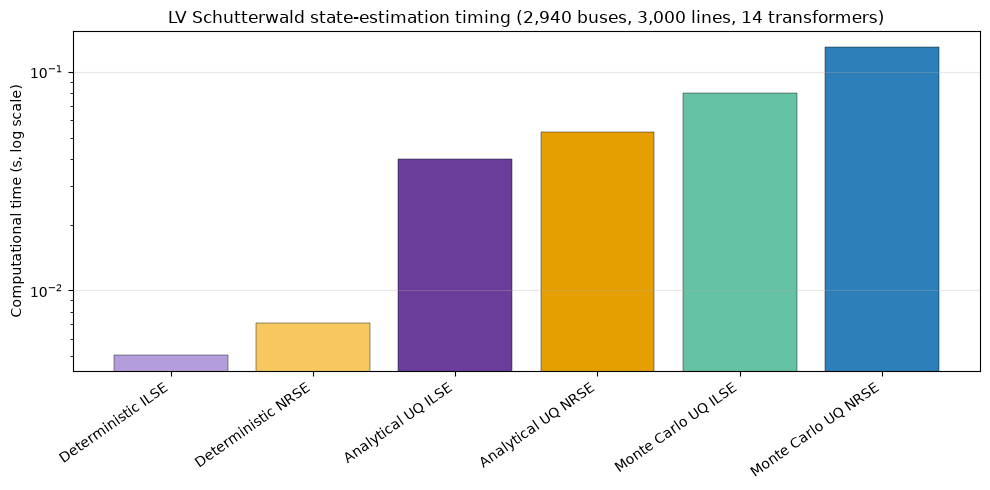

In [9]:
timing_figure, timing_axis = plt.subplots(figsize=(10, 5))
labels = [
    "Deterministic ILSE",
    "Deterministic NRSE",
    "Analytical UQ ILSE",
    "Analytical UQ NRSE",
    "Monte Carlo UQ ILSE",
    "Monte Carlo UQ NRSE",
]
values = [
    deterministic_seconds["Analytical UQ ILSE"],
    deterministic_seconds["Analytical UQ NRSE"],
    analytical_seconds["Analytical UQ ILSE"],
    analytical_seconds["Analytical UQ NRSE"],
    monte_carlo_seconds["Analytical UQ ILSE"],
    monte_carlo_seconds["Analytical UQ NRSE"],
]
timing_axis.bar(
    np.arange(len(values)),
    values,
    color=["#B39DDB", "#F6C85F", "#6A3D9A", "#E69F00", "#66C2A5", "#2C7FB8"],
    edgecolor="black",
    linewidth=0.3,
)
timing_axis.set_ylabel("Computational time (s, log scale)")
timing_axis.set_yscale("log")
timing_axis.set_xticks(np.arange(len(values)))
timing_axis.set_xticklabels(labels, rotation=35, ha="right")
timing_axis.grid(axis="y", visible=True, alpha=0.3)
timing_axis.set_title(f"LV Schutterwald state-estimation timing ({network_size_label})")
timing_figure.tight_layout()
timing_figure.savefig(figure_directory / "lv_schutterwald_uq_computational_time.pdf")
timing_figure.savefig(figure_directory / "lv_schutterwald_uq_computational_time.png", dpi=300)
plt.show()
plt.close(timing_figure)

## Interpretation

The analytical, gain-inverse, and Monte Carlo sigma columns estimate the same output uncertainties under their respective covariance models. Monte Carlo differences also reflect finite sampling. The exported CSV contains all 2,940 node-voltage rows and both measured line quantities for all 3,000 lines. Zero-flow branches with undefined analytical propagation are represented as `NaN`; the figures omit those rows and display up to the first 30 finite IDs for readability.

`UQ gain inv` is a conventional first-order NRSE covariance baseline evaluated at the converged PGM state. Because its gain matrix excludes the network's exact zero-injection constraints, differences from Analytical UQ NRSE are expected.
